# Notebook 05 — Modelos avanzados

**Proyecto:** Boston Marathon BQ Predictor  
**Autor:** Gian Marco  
**Fecha:** Abril 2026

## Objetivos

1. Entrenar Random Forest y XGBoost con hiperparámetros razonables (sin tuning exhaustivo hoy)
2. Comparar con los baselines del Notebook 04 usando las mismas métricas
3. Identificar el modelo candidato a ganador para los siguientes notebooks
4. Dejar el tuning con GridSearch para una segunda pasada posterior

## Regla fundamental

Sigue en vigor: el `test_features.csv` NO se toca. Toda comparación es vía CV sobre `train_features.csv`.

## Métrica de decisión

**F1-score de la clase positiva (BQ=1).** Mismas métricas complementarias que en el Notebook 04.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROCESSED_DATA_DIR = Path('../data/processed')
FIGURES_DIR = Path('../reports/figures')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

print('Setup listo')
print(f'XGBoost version: {xgb.__version__}')

Setup listo
XGBoost version: 3.2.0


---
## 1. Cargar datos y configuración de CV

Reutilizamos exactamente la misma configuración de CV del Notebook 04 para que los resultados sean comparables.

In [2]:
TRAIN_DIR = Path('../data/train')
train = pd.read_csv(TRAIN_DIR / 'train_features.csv')

X = train.drop(columns=['es_BQ'])
y = train['es_BQ']

if 'Year' in X.columns:
    X = X.drop(columns=['Year'])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'f1_pos': 'f1',
    'precision_pos': 'precision',
    'recall_pos': 'recall',
    'pr_auc': 'average_precision',
    'roc_auc': 'roc_auc',
}

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'% BQ: {y.mean()*100:.2f}%')

X shape: (225356, 22)
y shape: (225356,)
% BQ: 13.45%


---
## 2. Helper para resumir resultados

Reutilizamos la misma función del Notebook 04 para que la tabla consolidada final sea coherente entre notebooks.

In [3]:
def summarize_cv(cv_results, model_name):
    summary = {'model': model_name}
    for metric in scoring.keys():
        key = f'test_{metric}'
        summary[f'{metric}_mean'] = cv_results[key].mean()
        summary[f'{metric}_std'] = cv_results[key].std()
    summary['fit_time_mean'] = cv_results['fit_time'].mean()
    return summary

results = []
print('Helper listo')

Helper listo


---
## 3. Random Forest

Configuración:
- `n_estimators=200` — 200 árboles, sweet spot velocidad/rendimiento
- `max_depth=None` — sin límite; el ensemble previene overfitting individual
- `min_samples_leaf=20` — evita hojas con ruido (menos conservador que DT porque compensamos con muchos árboles)
- `n_jobs=-1` — paralelización total
- `random_state=42`

No aplicamos `class_weight='balanced'` aún — eso lo probaremos en el Notebook 06 para aislar el efecto.

In [4]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

print('Entrenando Random Forest (puede tardar ~1-2 min)...')
cv_out = cross_validate(rf, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
summary = summarize_cv(cv_out, 'RandomForest (200 trees, leaf=20)')
results.append(summary)

print(f"\nF1 (clase pos):  {summary['f1_pos_mean']:.4f} ± {summary['f1_pos_std']:.4f}")
print(f"Precision:       {summary['precision_pos_mean']:.4f}")
print(f"Recall:          {summary['recall_pos_mean']:.4f}")
print(f"PR-AUC:          {summary['pr_auc_mean']:.4f}")
print(f"ROC-AUC:         {summary['roc_auc_mean']:.4f}")
print(f"Tiempo fit medio: {summary['fit_time_mean']:.2f}s")

Entrenando Random Forest (puede tardar ~1-2 min)...

F1 (clase pos):  0.1306 ± 0.0075
Precision:       0.5926
Recall:          0.0734
PR-AUC:          0.3329
ROC-AUC:         0.7270
Tiempo fit medio: 16.93s


---
## 4. XGBoost

Configuración:
- `n_estimators=200` — 200 árboles secuenciales
- `max_depth=6` — profundidad moderada (defaults de XGBoost)
- `learning_rate=0.1` — cuánto aprende cada árbol nuevo
- `tree_method='hist'` — algoritmo moderno, rápido con datos grandes
- `eval_metric='logloss'` — métrica interna durante entrenamiento
- `random_state=42`

In [5]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    tree_method='hist',
    eval_metric='logloss',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

print('Entrenando XGBoost (puede tardar ~30-60s)...')
cv_out = cross_validate(xgb_model, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
summary = summarize_cv(cv_out, 'XGBoost (200 trees, depth=6, lr=0.1)')
results.append(summary)

print(f"\nF1 (clase pos):  {summary['f1_pos_mean']:.4f} ± {summary['f1_pos_std']:.4f}")
print(f"Precision:       {summary['precision_pos_mean']:.4f}")
print(f"Recall:          {summary['recall_pos_mean']:.4f}")
print(f"PR-AUC:          {summary['pr_auc_mean']:.4f}")
print(f"ROC-AUC:         {summary['roc_auc_mean']:.4f}")
print(f"Tiempo fit medio: {summary['fit_time_mean']:.2f}s")

Entrenando XGBoost (puede tardar ~30-60s)...

F1 (clase pos):  0.1667 ± 0.0072
Precision:       0.5564
Recall:          0.0981
PR-AUC:          0.3356
ROC-AUC:         0.7361
Tiempo fit medio: 1.80s


---
## 5. Tabla comparativa consolidada — baselines + avanzados

Cargamos los resultados del Notebook 04 y los unimos con los de este notebook para tener una comparación única.

In [6]:
# Cargar baselines del Notebook 04
baseline_results = pd.read_csv(PROCESSED_DATA_DIR / 'baseline_results.csv')

# Añadir resultados de este notebook
current_results_df = pd.DataFrame(results)
all_results = pd.concat([baseline_results, current_results_df], ignore_index=True)

# Ordenar por F1 descendente
all_results = all_results.sort_values('f1_pos_mean', ascending=False).reset_index(drop=True)

# Tabla bonita para mostrar
metric_cols = ['f1_pos_mean', 'precision_pos_mean', 'recall_pos_mean', 'pr_auc_mean', 'roc_auc_mean']
display_df = all_results[['model'] + metric_cols + ['fit_time_mean']].copy()
display_df.columns = ['Modelo', 'F1 (pos)', 'Precision', 'Recall', 'PR-AUC', 'ROC-AUC', 'Fit (s)']

for col in ['F1 (pos)', 'Precision', 'Recall', 'PR-AUC', 'ROC-AUC']:
    display_df[col] = display_df[col].apply(lambda x: f'{x:.4f}')
display_df['Fit (s)'] = display_df['Fit (s)'].apply(lambda x: f'{x:.2f}')

print('RANKING CONSOLIDADO (baselines + avanzados)')
print('=' * 100)
print(display_df.to_string(index=False))

RANKING CONSOLIDADO (baselines + avanzados)
                              Modelo F1 (pos) Precision Recall PR-AUC ROC-AUC Fit (s)
XGBoost (200 trees, depth=6, lr=0.1)   0.1667    0.5564 0.0981 0.3356  0.7361    1.80
                  LogisticRegression   0.1666    0.5488 0.0982 0.3276  0.7286    0.53
     DecisionTree (depth=8, leaf=50)   0.1506    0.5693 0.0870 0.3263  0.7316    0.30
                  Dummy (stratified)   0.1378    0.1380 0.1376 0.1350  0.5020    0.04
   RandomForest (200 trees, leaf=20)   0.1306    0.5926 0.0734 0.3329  0.7270   16.93
               Dummy (most_frequent)   0.0000    0.0000 0.0000 0.1345  0.5000    0.07


---
## 6. Visualización comparativa

Gráfico de barras con los 6 modelos en las 3 métricas clave. Debería mostrar visualmente cómo F1 se estanca pero PR-AUC y ROC-AUC mejoran ligeramente con los modelos avanzados.

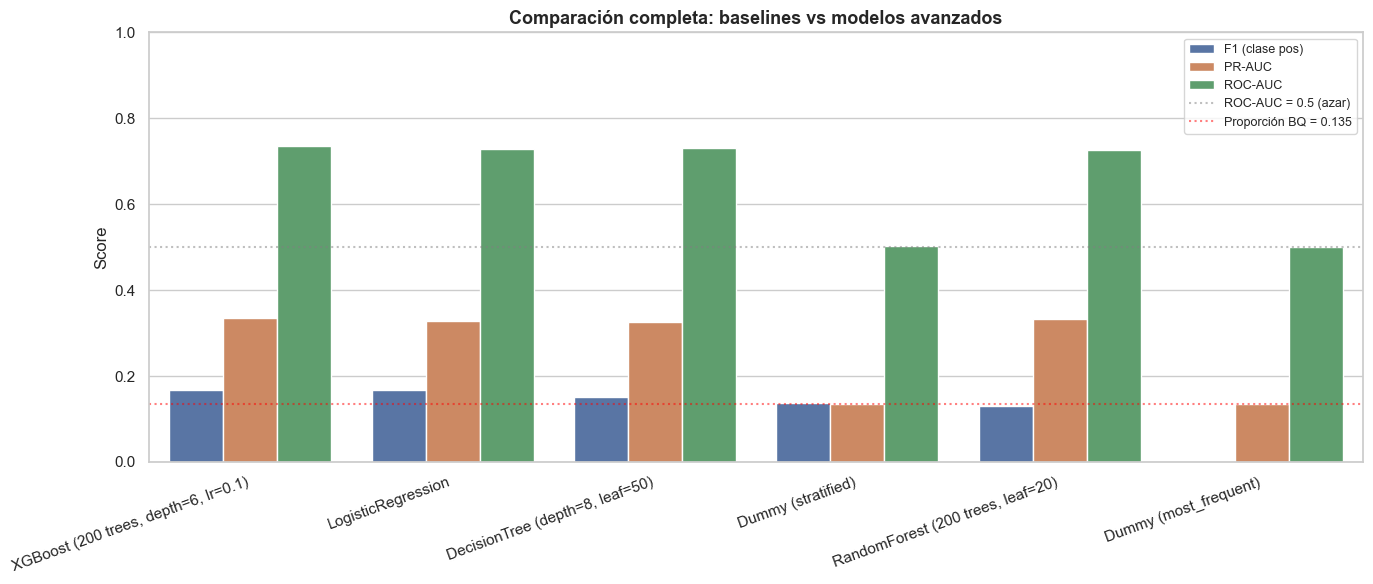

In [7]:
plot_df = all_results[['model', 'f1_pos_mean', 'pr_auc_mean', 'roc_auc_mean']].copy()
plot_df = plot_df.melt(id_vars='model', var_name='metric', value_name='score')
plot_df['metric'] = plot_df['metric'].map({
    'f1_pos_mean': 'F1 (clase pos)',
    'pr_auc_mean': 'PR-AUC',
    'roc_auc_mean': 'ROC-AUC',
})

model_order = all_results['model'].tolist()

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=plot_df, x='model', y='score', hue='metric',
            order=model_order, palette='deep', ax=ax, edgecolor='white')

ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5, label='ROC-AUC = 0.5 (azar)')
ax.axhline(y.mean(), color='red', linestyle=':', alpha=0.5, label=f'Proporción BQ = {y.mean():.3f}')

ax.set_title('Comparación completa: baselines vs modelos avanzados',
             fontweight='bold', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', fontsize=9)
plt.xticks(rotation=20, ha='right')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '09_advanced_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Guardar resultados consolidados

In [8]:
all_results.to_csv(PROCESSED_DATA_DIR / 'advanced_results.csv', index=False)
print(f'Resultados guardados en: {PROCESSED_DATA_DIR / "advanced_results.csv"}')

Resultados guardados en: ../data/processed/advanced_results.csv


---
## 8. Conclusiones del Notebook 05

### Hallazgo central — Los modelos no-lineales empatan en F1, pero ganan en AUC

| Métrica | LogReg | XGBoost | RF | Delta vs LogReg |
|---|---|---|---|---|
| F1 (pos) | 0.167 | 0.167 | 0.131 | XGB empata, RF -0.036 |
| PR-AUC | 0.328 | 0.336 | 0.333 | XGB +0.008, RF +0.005 |
| ROC-AUC | 0.729 | 0.736 | 0.727 | XGB +0.007, RF -0.002 |

**Diagnóstico:** los modelos aprenden mejores rankings de probabilidad (PR-AUC y ROC-AUC superiores en XGBoost), pero el threshold de decisión fijo en 0.5 está mal calibrado para la distribución 87/13. Todos los modelos reales convergen a precision ~55-60% y recall ~7-10%, lo cual es el síntoma clásico de **desbalance + threshold conservador**.

### ¿Por qué Random Forest queda por debajo de LogReg en F1?

Con `min_samples_leaf=20` y 200 árboles promediando, las probabilidades de RF quedan suaves (cercanas a la proporción base 0.135). Casi ninguna cruza el umbral 0.5. LogReg, con frontera lineal, produce probabilidades más polarizadas. Este es un **problema de calibración + threshold**, no de capacidad del modelo.

### ¿Por qué XGBoost solo empata a LogReg?

Misma razón: threshold 0.5 limita artificialmente el F1 de todos los modelos que "respetan" el desbalance. XGBoost tiene ligera ventaja en AUC (aprende mejor el ranking), pero al aplicar el threshold la ventaja se pierde.

### Ganador de esta fase — XGBoost

A pesar del empate en F1, XGBoost es el candidato a mejor modelo porque:
- PR-AUC ligeramente superior (0.336)
- ROC-AUC más alto (0.736)
- Fit time razonable (1.84s) — muy rápido para tuning futuro
- Manejo nativo de desbalance vía `scale_pos_weight` (lo probaremos en N06)

### Próximos pasos

**Notebook 06 — Desbalance:** aplicar `class_weight='balanced'` y SMOTE al XGBoost. Esperamos el primer salto grande en F1.

**Notebook 07 — Threshold tuning:** buscar el threshold óptimo por F1 en CV. Esperamos salto adicional.

**Notebook 08 — Interpretabilidad:** SHAP sobre el modelo final elegido.

### Decisión aplazada

El tuning exhaustivo de hiperparámetros con GridSearch lo dejamos fuera de este notebook porque:
- El cuello de botella actual es el threshold/desbalance, no los hiperparámetros
- Una vez resuelto el desbalance, volveremos a tunear con foco y menos ruido
- Alternativa: un quick tuning rápido en el Notebook 06 sobre el mejor modelo post-desbalance